# 5 — Is it calibrated, and what can it resolve?

*Series: **Bayesian fluorescence decays**, notebook 5 of 8. Builds §7 of
`THEORY.md`.*

**What this notebook establishes.** That a posterior which fits is not thereby
a posterior that is right; how to check; what the check found for this model;
and how close two populations can be before it stops seeing two.

---

## Two different questions

Notebook 4 produced intervals. There are two ways they can be wrong and they
need different tests.

**Does the model describe the data?** The Poisson deviance and the runs test
on the weighted residuals. A model with the wrong shape has structured
residuals even when its total misfit is unremarkable.

**Do the intervals contain the truth as often as they claim?** Nothing about
the fit answers this. It is answered by simulating truths, fitting them, and
counting. If

$$
\theta^\ast\sim\pi(\theta),\qquad y\sim p(y\mid\theta^\ast),\qquad
u = \Pr\big(T(\theta) < T(\theta^\ast)\,\big|\,y\big),
$$

then $u$ is **uniform on $[0,1]$** whenever the posterior is exact — that is
simulation-based calibration (Talts, Betancourt, Simpson, Vehtari & Gelman,
arXiv:1804.06788). Non-uniformity says which way it is wrong: a hump in the
middle means intervals too wide, weight at both ends means too narrow, a
tilt means a bias.

Here $u$ is available in closed form, because the posterior is a mixture of
Gaussians and $T$ is summarised by the delta method:
$u=\sum_\ell w_\ell\,\Phi\big((T^\ast-\mu_\ell)/\sigma_\ell\big)$.

In [1]:
import sys, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt
import bd
bd.keep_inline()          # the prototype's modules switch matplotlib to a file backend on import

S = bd.default_settings(); S['threads'] = 4
model = bd.build_model(S)
L, rel = model['L'], model['rel']
lo_w, hi_w = bd.window(0.01)
print(f'the usable window is R/R0 in [{lo_w:.2f}, {hi_w:.2f}]')

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
the usable window is R/R0 in [0.46, 2.15]


## A small calibration run, to show the mechanism

Twelve truths, each one or two Gaussian populations inside the window, at
$10^5$ photons per sample — a deliberately modest measurement so the fits are
quick. For each, the whole procedure runs and the rank of the truth is
recorded.

**This is a demonstration of the mechanism, not the calibration.** Twelve
truths give ranks whose histogram is dominated by counting noise; and the
truths are drawn from a family of Gaussian mixtures rather than from the
model's own prior, which makes this a coverage check over a declared
population of truths rather than strict simulation-based calibration. The
real runs — a thousand truths from the model's prior, and two hundred per cell
of a shape-by-photon-count grid — are the figures further down.

In [2]:
rng = np.random.default_rng(4)
names = ('x_d0', 'mean', 'sd', 'tail', 'r0_d', 'r0_a', 'g')
ranks = {n: [] for n in names}; stats = []
t0 = time.time()
for i in range(12):
    k = 1 + int(rng.random() < 0.5)
    ctr = np.sort(rng.uniform(0.75, 1.25, k))
    if k == 2 and ctr[1] - ctr[0] < 0.15:
        ctr[1] = ctr[0] + 0.15
    wts = rng.dirichlet(np.ones(k))
    wid = rng.uniform(0.05, 0.12, k)
    x0 = float(rng.uniform(0.05, 0.35))
    p_i = bd.gaussian_truth(model, ctr, wts, wid)
    y_i, _, _ = bd.simulate_ensemble(model, S, p_i, x_d0=x0, photons=1e5, seed=100 + i)
    nodes = [bd.fit_at_lambda(model, y_i, lg) for lg in (1.0, -0.5)]
    post = bd.mix_nodes(nodes)
    mu = float((p_i * rel).sum())
    truth = dict(x_d0=x0, mean=mu, sd=float(np.sqrt((p_i * (rel - mu) ** 2).sum())),
                 tail=float(p_i[rel > 1.3].sum()), r0_d=S['r0_donor'], r0_a=S['r0_acceptor'], g=L.S.G_TRUE)
    mom = L.mixture_summary_moments(post['graph'], post, rel)
    for n in names:
        ranks[n].append(float(L.mixture_cdf(mom, n, truth[n])))
    ref, ref_sd = bd.poisson_reference(post, 100, i)
    stats.append((post['dev'] / post['dof'], ref, ref_sd))
    print(f'  truth {i:2d}: {k} population(s) at ' + ', '.join(f'{c:.2f}' for c in ctr) +
          f", D/dof {post['dev']/post['dof']:.3f} (reference {ref:.3f}), {time.time()-t0:.0f} s total", flush=True)
print(f'\n{len(stats)} fits in {time.time()-t0:.0f} s')

  truth  0: 1 population(s) at 1.01, D/dof 0.971 (reference 1.055), 57 s total


  truth  1: 2 population(s) at 0.84, 1.15, D/dof 1.084 (reference 1.047), 95 s total


  truth  2: 1 population(s) at 1.24, D/dof 1.001 (reference 1.056), 146 s total


  truth  3: 2 population(s) at 1.05, 1.20, D/dof 1.086 (reference 1.053), 192 s total


  truth  4: 1 population(s) at 1.23, D/dof 1.042 (reference 1.060), 249 s total


...

  truth  8: 1 population(s) at 1.02, D/dof 1.048 (reference 1.055), 447 s total


  truth  9: 2 population(s) at 0.96, 1.24, D/dof 0.994 (reference 1.061), 484 s total


  truth 10: 1 population(s) at 0.80, D/dof 1.015 (reference 1.040), 529 s total


  truth 11: 2 population(s) at 0.79, 1.14, D/dof 1.031 (reference 1.053), 570 s total



12 fits in 570 s


quantity   mean rank   in [0.025,0.975]
x_d0           0.623           12 of 12
mean           0.481           12 of 12
sd             0.216           12 of 12
tail           0.382           12 of 12
r0_d           0.737           12 of 12
r0_a           0.677           12 of 12
g              0.714           11 of 12

fits within one sd of their reference: 7 of 12


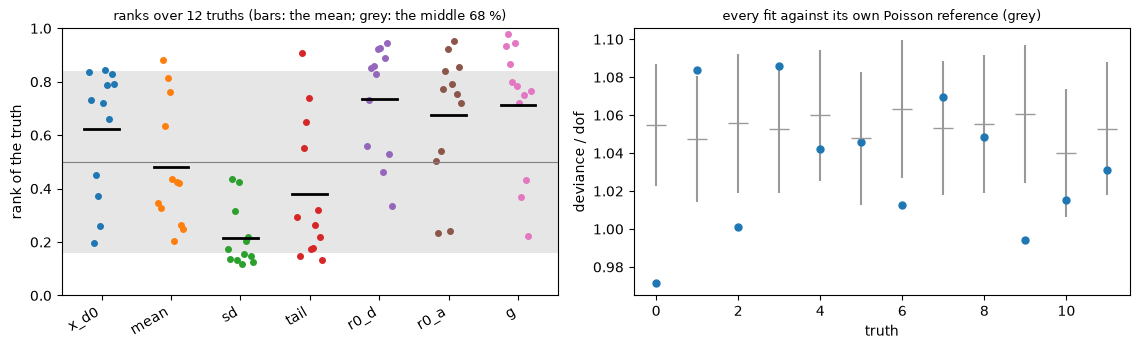

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
for i, n in enumerate(names):
    u = np.array(ranks[n])
    ax[0].plot(np.full(len(u), i) + np.linspace(-0.18, 0.18, len(u)), u, 'o', ms=4, color=f'C{i%10}')
    ax[0].plot([i - 0.25, i + 0.25], [u.mean()] * 2, 'k-', lw=2)
ax[0].axhspan(0.16, 0.84, color='0.9', zorder=0, lw=0)
ax[0].axhline(0.5, color='0.5', lw=0.8)
ax[0].set_xticks(range(len(names))); ax[0].set_xticklabels(names, rotation=30, ha='right')
ax[0].set_ylabel('rank of the truth'); ax[0].set_ylim(0, 1)
ax[0].set_title('ranks over 12 truths (bars: the mean; grey: the middle 68 %)', fontsize=9)
d = np.array([s[0] for s in stats]); r_ = np.array([s[1] for s in stats]); rs = np.array([s[2] for s in stats])
ax[1].errorbar(np.arange(len(d)), r_, yerr=rs, fmt='_', color='0.6', ms=14)
ax[1].plot(np.arange(len(d)), d, 'C0o', ms=5)
ax[1].set_xlabel('truth'); ax[1].set_ylabel('deviance / dof')
ax[1].set_title('every fit against its own Poisson reference (grey)', fontsize=9)
fig.tight_layout()
print(f"{'quantity':<9}{'mean rank':>11}{'in [0.025,0.975]':>19}")
for n in names:
    u = np.array(ranks[n])
    print(f'{n:<9}{u.mean():>11.3f}{int(((u > 0.025) & (u < 0.975)).sum()):>13d} of {len(u)}')
print(f"\nfits within one sd of their reference: {int((np.abs(d-r_) < rs).sum())} of {len(d)}")

## The real calibration runs

Twelve truths cannot settle this. The two figures below are the runs that did:
a thousand truths drawn from the model's own prior (tier 1), and two hundred
truths per cell of a grid over the *shape* of the distribution and the photon
count (tier 2). Both were computed with the same code this series uses.

### Tier 1 — truths from the prior

![tier 1](figures/20260906T215444_s88_S4d_merged.png)

*A thousand truths. Each panel is one reported quantity: the rank histogram
against the uniform it should be, with the Kolmogorov–Smirnov distance beside
its threshold, the coverage of the nominal 68 % and 95 % intervals, and the
bias in units of the posterior standard deviation.*

The calibration constants — the g factor, both anisotropies, the crosstalks —
pass. The distribution's own summaries do not pass cleanly, and the direction
is consistent: the width and the far-tail mass come out high, the donor-only
fraction low.

### Tier 2 — the same, per shape and photon count

![tier 2](figures/20260907T163255_s88_S5fix_merged.png)

*Two hundred realisations per cell. Rows are the shape of the truth — one
population, two, three, a broad one — and columns the photons per sample.*

This is where the method's **domain** is written down rather than asserted. A
single population is recovered well at every photon count. Two populations
need $10^6$. Three are not fully separated even at $10^7$: the smoothing
prior's cost on a sharp feature is paid as width, and the third population
partly merges.

## Where the bias comes from — the part that was a dead end

The width-high, donor-only-low trade was chased for a day. It is worth
recording what it was **not**, because each of those was a plausible
explanation that had to be excluded by measurement:

* not the summary method — the second-order delta correction moves it by a
  fraction of the effect, and a tilted-Laplace summary agrees;
* not the penalty's order or space — order 3 has the same bias with narrower
  bands, and the alternative spaces are worse;
* not an unpinned calibration constant — fixing them one at a time does not
  remove it;
* not the prior widths — tightening *or* loosening them both make it worse;
* not the position of the joint mode, beyond about a fifth of the effect,
  which an analytic marginalisation over the three sample scales recovers.

What it is: one nearly degenerate direction that trades the sample scales, the
donor-only fraction and the direct-excitation probability against a weak-FRET
shoulder at 1.3–1.5 $R/R_0$. Information the nuisances do not pin down is
absorbed by $p(R)$ as width, and paid for out of the donor-only fraction.

![the bias](figures/20260908T053454_s88_S11bias.png)

*The degenerate direction, and the summaries' response along it.*

The remedy is not a better estimator. It is a better experiment, and notebook
6 measures which one.

## Resolution: how close is too close

The other question a distance distribution has to answer about itself is what
it can separate. This was measured by refitting two-population truths at a
grid of centres and separations, at high photon count so that the answer is
about the method and not the counting:

![resolution](figures/20260908T121137_s88_S14res_ord2.png)

*Two populations of width 0.06 $R/R_0$, at a grid of centres and separations.
Green: two peaks recovered. The rule that comes out: reliably separated from a
separation of 0.30, sometimes at 0.20, never at 0.15 — and never at all above
about 1.4 $R/R_0$, where the truth is no longer representable on the grid.*

The same thing said as a kernel: refit a single noiseless population and see
how wide it comes back.

![kernel](figures/20260908T121156_s88_S14kernel.png)

*The recovered width of a delta population, against where it sits. 0.018
$R/R_0$ at the Förster radius, rising to 0.161 at 1.7 — the ruler's marks get
further apart exactly as $\mathrm{d}E/\mathrm{d}r$ predicted in notebook 1.*

The demonstration below reproduces the middle of that in three fits.

  separation 0.30: 2 peak(s) recovered, D/dof 1.087, 51 s total


  separation 0.20: 2 peak(s) recovered, D/dof 1.051, 117 s total


  separation 0.12: 1 peak(s) recovered, D/dof 1.053, 163 s total


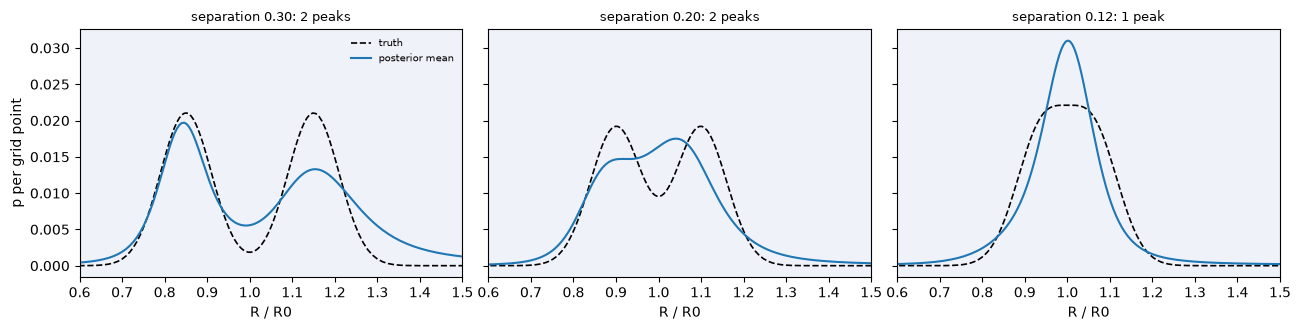

In [4]:
t0 = time.time()
out = []
for sep in (0.30, 0.20, 0.12):
    p_i = bd.gaussian_truth(model, [1.0 - sep / 2, 1.0 + sep / 2], [0.5, 0.5], 0.06)
    y_i, _, _ = bd.simulate_ensemble(model, S, p_i, x_d0=0.15, photons=1e6, seed=77)
    nodes = [bd.fit_at_lambda(model, y_i, lg) for lg in (0.5, -1.0)]
    post = bd.mix_nodes(nodes)
    m = L.delta_bands(None, post, rel, space='linear')[0]
    inside = (rel > 0.6) & (rel < 1.5)
    d2 = np.diff(np.sign(np.diff(m[inside])))
    peaks = int((d2 < 0).sum())
    out.append((sep, p_i, m, peaks, post))
    print(f'  separation {sep:.2f}: {peaks} peak(s) recovered, D/dof {post["dev"]/post["dof"]:.3f}, '
          f'{time.time()-t0:.0f} s total', flush=True)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for a, (sep, p_i, m, peaks, post) in zip(ax, out):
    a.plot(rel, p_i, 'k--', lw=1.2, label='truth')
    a.plot(rel, m, 'C0', lw=1.5, label='posterior mean')
    a.set_xlim(0.6, 1.5); a.set_xlabel('R / R0')
    a.set_title(f'separation {sep:.2f}: {peaks} peak' + ('s' if peaks != 1 else ''), fontsize=9)
    L.shade_window(a, 0.01, label=False)
ax[0].set_ylabel('p per grid point'); ax[0].legend(fontsize=7, frameon=False)
fig.tight_layout()

## The window, once more, because it is the most common way to over-read a figure

$E(r)=1/(1+r^6)$ saturates, so outside

$$
r\in\Big[\big(\tfrac{\delta}{1-\delta}\big)^{1/6},\ \big(\tfrac{1-\delta}{\delta}\big)^{1/6}\Big]
\;=\;[0.46,\ 2.15]\ \text{ at }\delta=0.01,
$$

a change in distance moves the decay by less than $\delta$ in efficiency. A
posterior still puts a curve there, because the prior does. Every figure in
this series greys it, which is chisurf's convention, and no number is quoted
from inside the grey.

## What comes next

The calibration says the errors are in $p(R)$'s width and the donor-only
fraction, and the diagnosis says they come from nuisances the current
measurement does not pin down. Notebook 6 changes the measurement instead of
the estimator, and measures what that buys.

**Established here.** Simulation-based calibration and the closed-form rank
(THEORY §6.3, §7.2), demonstrated on twelve truths; the real tier-1 and
tier-2 runs and what they found; the bias, and the five explanations excluded
by measurement; the resolution rule and the resolution kernel (§7.3); and the
window.